In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix


SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [30]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/sampreetibasak
/kaggle/input/datasets/sampreetibasak/fer-2013
/kaggle/input/datasets/sampreetibasak/fer-2013/test
/kaggle/input/datasets/sampreetibasak/fer-2013/test/surprise
/kaggle/input/datasets/sampreetibasak/fer-2013/test/fear
/kaggle/input/datasets/sampreetibasak/fer-2013/test/angry
/kaggle/input/datasets/sampreetibasak/fer-2013/test/neutral
/kaggle/input/datasets/sampreetibasak/fer-2013/test/sad
/kaggle/input/datasets/sampreetibasak/fer-2013/test/disgust
/kaggle/input/datasets/sampreetibasak/fer-2013/test/happy
/kaggle/input/datasets/sampreetibasak/fer-2013/train
/kaggle/input/datasets/sampreetibasak/fer-2013/train/surprise
/kaggle/input/datasets/sampreetibasak/fer-2013/train/fear
/kaggle/input/datasets/sampreetibasak/fer-2013/train/angry
/kaggle/input/datasets/sampreetibasak/fer-2013/train/neutral
/kaggle/input/datasets/sampreetibasak/fer-2013/train/sad
/kaggle/input/datasets/sampreetibasak/fer-2013/train/disgust
/kagg

In [31]:
TRAIN_DIR = "/kaggle/input/datasets/sampreetibasak/fer-2013/train"
TEST_DIR  = "/kaggle/input/datasets/sampreetibasak/fer-2013/test"

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
NUM_CLASSES = 7

class_names = sorted(os.listdir(TRAIN_DIR))
print("Classes:", class_names)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


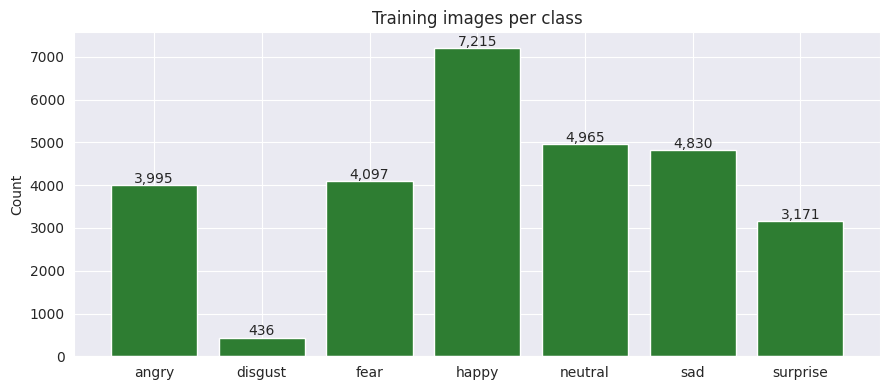

Total training images: 28,709


In [32]:
counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in class_names}

plt.figure(figsize=(9, 4))
bars = plt.bar(counts.keys(), counts.values(), color="#2e7d32")
plt.title("Training images per class")
plt.ylabel("Count")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 50,
             f"{int(b.get_height()):,}", ha="center")
plt.tight_layout()
plt.show()

print(f"Total training images: {sum(counts.values()):,}")

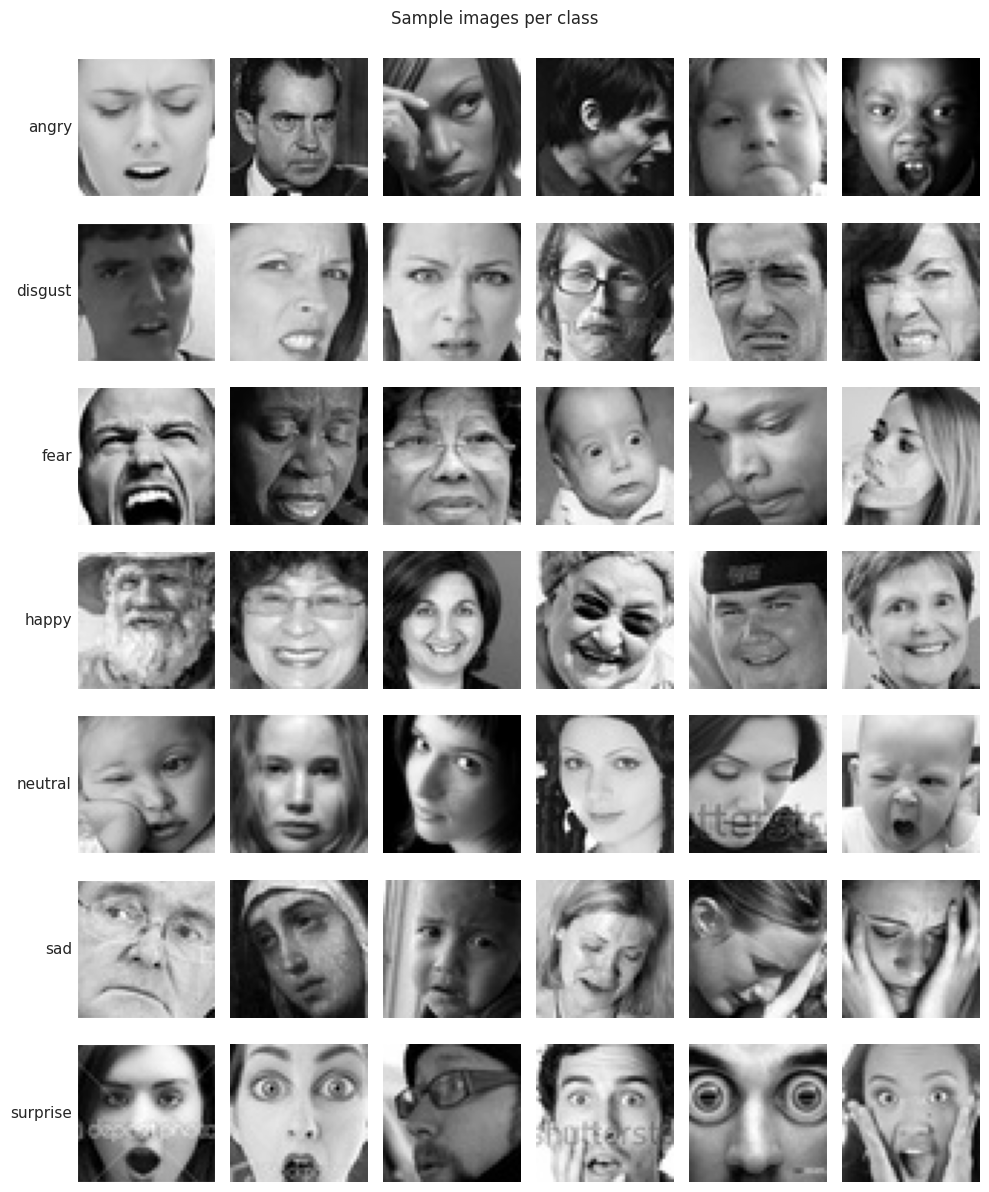

In [33]:
fig, axes = plt.subplots(len(class_names), 6, figsize=(10, 12))
for row, cls in enumerate(class_names):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files = os.listdir(cls_dir)[:6]
    for col, fname in enumerate(files):
        img = keras.utils.load_img(os.path.join(cls_dir, fname), color_mode="grayscale")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls)
    axes[row, 0].axis("on")
    axes[row, 0].set_yticks([]); axes[row, 0].set_xticks([])
    axes[row, 0].set_ylabel(cls, rotation=0, ha="right", va="center", fontsize=11)
plt.suptitle("Sample images per class", y=0.995)
plt.tight_layout()
plt.show()

In [34]:
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.1,
    subset="training",
    seed=SEED,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.1,
    subset="validation",
    seed=SEED,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,  
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Found 28709 files belonging to 7 classes.
Using 25839 files for training.
Found 28709 files belonging to 7 classes.
Using 2870 files for validation.
Found 7178 files belonging to 7 classes.


In [35]:
total = sum(counts.values())
class_weight = {
    i: total / (NUM_CLASSES * counts[c])
    for i, c in enumerate(class_names)
}
class_weight

{0: 1.0266046844269623,
 1: 9.406618610747051,
 2: 1.0010460615781582,
 3: 0.5684387684387684,
 4: 0.8260394187886635,
 5: 0.8491274770777877,
 6: 1.293372978330405}

In [36]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.08, 0.08),
], name="augmentation")

def build_model():
    inputs = keras.Input(shape=(48, 48, 1))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="fer_cnn")

model = build_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "fer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             

 Total params: 3,510,215 (13.39 MB)

 Trainable params: 3,507,911 (13.38 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [39]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=10, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_fer_cnn.keras", monitor="val_accuracy", save_best_only=True
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.3052 - loss: 1.7556 - val_accuracy: 0.3990 - val_loss: 1.5629 - learning_rate: 0.0010
Epoch 2/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.3631 - loss: 1.6342 - val_accuracy: 0.4192 - val_loss: 1.5180 - learning_rate: 0.0010
Epoch 3/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.3998 - loss: 1.5602 - val_accuracy: 0.4300 - val_loss: 1.4891 - learning_rate: 0.0010
Epoch 4/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.4335 - loss: 1.4776 - val_accuracy: 0.4551 - val_loss: 1.4469 - learning_rate: 0.0010
Epoch 5/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.4472 - loss: 1.4500 - val_accuracy: 0.4941 - val_loss: 1.3306 - learning_rate: 0.0010
Epoch 6/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.4623 - loss: 1.3987 - val_accuracy: 0.4707 - val_loss: 1.3853 - learning_rate: 0.0010
Epoch 7/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.4623 - l

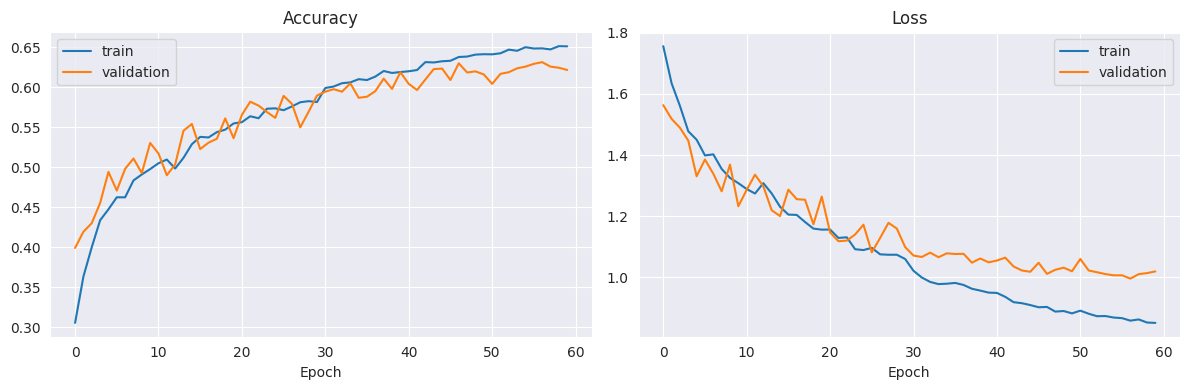

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


In [41]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.6336
Test loss:     0.9942


In [42]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       angry       0.51      0.59      0.55       958
     disgust       0.52      0.62      0.57       111
        fear       0.49      0.43      0.46      1024
       happy       0.90      0.81      0.85      1774
     neutral       0.56      0.64      0.60      1233
         sad       0.53      0.46      0.49      1247
    surprise       0.72      0.79      0.75       831

    accuracy                           0.63      7178
   macro avg       0.60      0.62      0.61      7178
weighted avg       0.64      0.63      0.63      7178



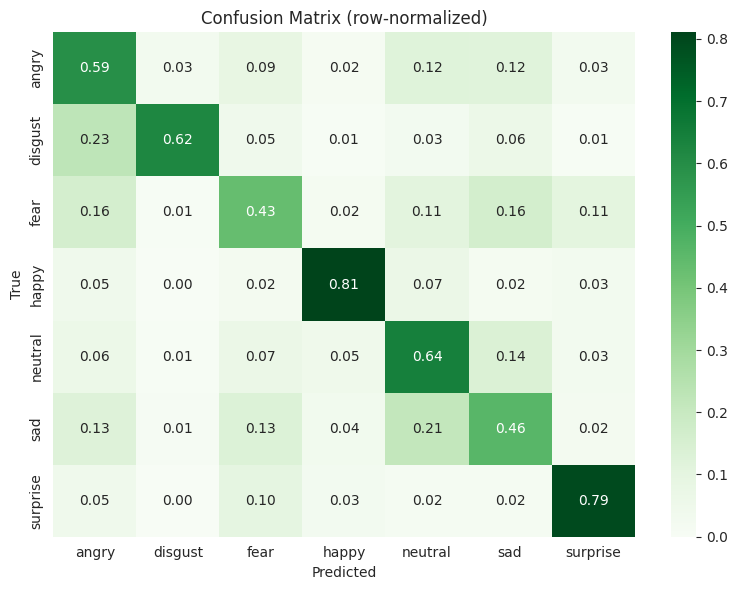

In [43]:
cm = confusion_matrix(y_true, y_pred, normalize="true")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (row-normalized)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()

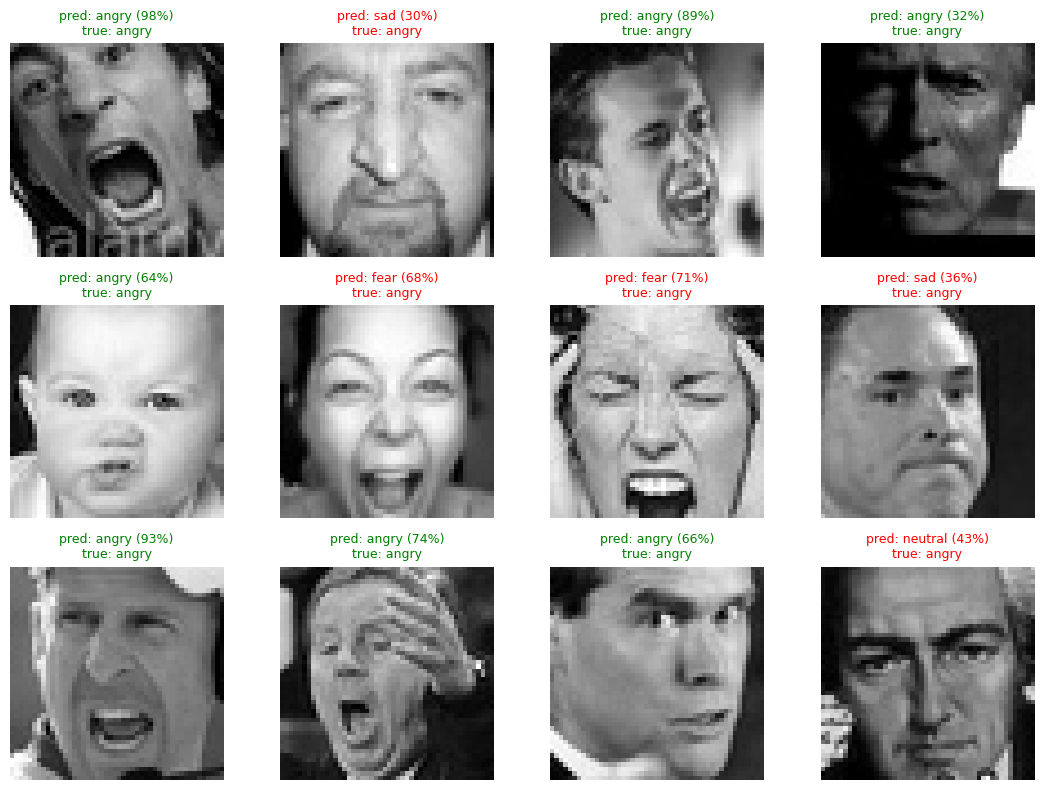

In [44]:
images = np.concatenate([x.numpy() for x, _ in test_ds.take(2)])
labels = np.concatenate([y.numpy() for _, y in test_ds.take(2)])
probs = model.predict(test_ds.take(2), verbose=0)
preds = np.argmax(probs, axis=1)

idx = np.random.choice(len(images), 12, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(images[i].squeeze(), cmap="gray")
    correct = preds[i] == labels[i]
    ax.set_title(
        f"pred: {class_names[preds[i]]} ({probs[i][preds[i]]:.0%})\ntrue: {class_names[labels[i]]}",
        color="green" if correct else "red", fontsize=9,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("PATH:", root)
    print("FILES:", files[:10])
    print("----------------")

PATH: /kaggle/input
FILES: []
----------------
PATH: /kaggle/input/datasets
FILES: []
----------------
PATH: /kaggle/input/datasets/sampreetibasak
FILES: []
----------------
PATH: /kaggle/input/datasets/sampreetibasak/fer-2013
FILES: []
----------------
PATH: /kaggle/input/datasets/sampreetibasak/fer-2013/test
FILES: []
----------------
PATH: /kaggle/input/datasets/sampreetibasak/fer-2013/test/surprise
FILES: ['PublicTest_78686873.jpg', 'PrivateTest_58522921.jpg', 'PrivateTest_83796714.jpg', 'PublicTest_84428313.jpg', 'PrivateTest_87978901.jpg', 'PrivateTest_90978621.jpg', 'PrivateTest_27580582.jpg', 'PublicTest_15760011.jpg', 'PublicTest_49739228.jpg', 'PublicTest_5351857.jpg']
----------------
PATH: /kaggle/input/datasets/sampreetibasak/fer-2013/test/fear
FILES: ['PublicTest_67261410.jpg', 'PrivateTest_80486885.jpg', 'PrivateTest_29930852.jpg', 'PublicTest_61256129.jpg', 'PrivateTest_86063456.jpg', 'PublicTest_24599099.jpg', 'PrivateTest_87242310.jpg', 'PublicTest_61582364.jpg', 'Pub